device → cuda


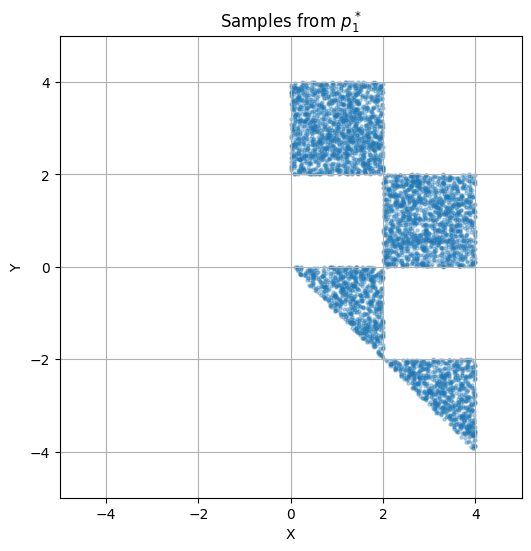

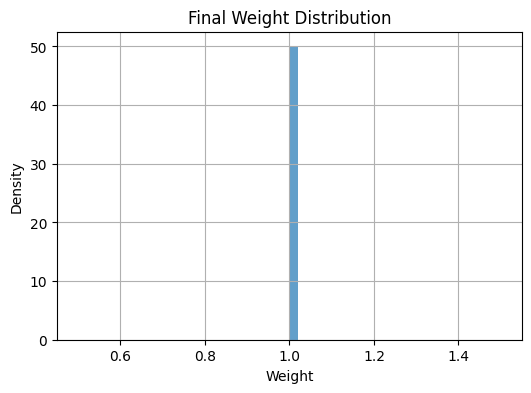

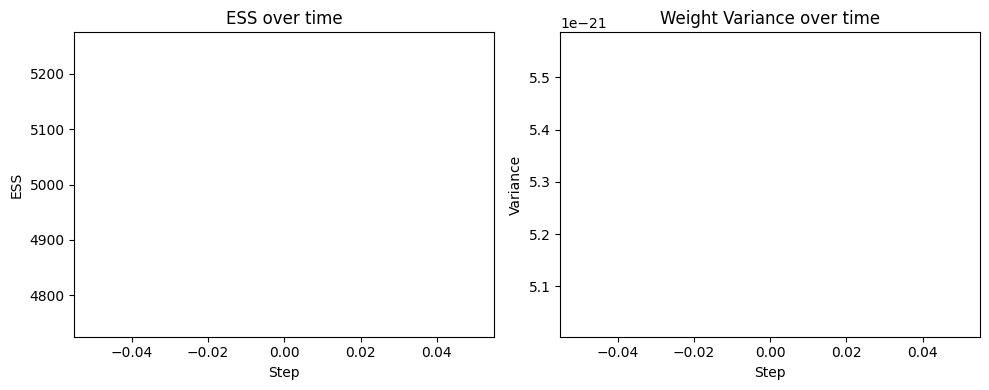

In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import random, os
from datetime import datetime
import os
import torch
import numpy as np
import pandas as pd
from utils.metrics.export import compute_sample_based_metrics
from hcg.interpolant import MLPInstFlexible, run_training_v_s
from hcg.sample_data import sample_checkerboard, make_conditions, sample_data_model1, sample_data_model2, sample_data_model3, ground_truth_hcg, plot_diagnostics
from hcg.hcg import simulate_hcg, simulate_hcg_generalized

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(0); random.seed(0); np.random.seed(0)
print("device →", device)

### Run this ONCE per experiment
new_experiment = False  # Set to False to reuse an old experiment ID
if new_experiment:  # Run the experiment with the current date and time as the experiment ID
    experiment_id = f"experiment_checker_{datetime.now().strftime('%Y%m%d')}" #_%H%M%S
    os.makedirs(experiment_id, exist_ok=True)
else:
    experiment_id = "experiment_checker_20250830"  # Use a fixed ID for reproducibility

bs = 5000
A, B = 1, 1  # Conditions to use for training
# plot ground truth
samples_gt = ground_truth_hcg(bs, cond_A=A, cond_B=B).cpu().numpy()
plot_diagnostics(samples_gt, torch.zeros(bs), [torch.zeros(bs)], save_name=f"{experiment_id}/ground_truth")

# With Pretrained Models

In [2]:
# Load all the models
u_model1 = MLPInstFlexible(z_dim=1, cond_dim=1, width=256, depth=4, output_dim=1).to(device); u_model1.load_state_dict(torch.load(f"{experiment_id}/u_model1_X_given_A.pth")); u_model1.eval()
s_model1 = MLPInstFlexible(z_dim=1, cond_dim=1, width=256, depth=4, output_dim=1).to(device); s_model1.load_state_dict(torch.load(f"{experiment_id}/s_model1_X_given_A.pth")); s_model1.eval()
u_model2 = MLPInstFlexible(z_dim=2, cond_dim=1, width=256, depth=4, output_dim=2).to(device); u_model2.load_state_dict(torch.load(f"{experiment_id}/u_model2_XY_given_B.pth")); u_model2.eval()
s_model2 = MLPInstFlexible(z_dim=2, cond_dim=1, width=256, depth=4, output_dim=2).to(device); s_model2.load_state_dict(torch.load(f"{experiment_id}/s_model2_XY_given_B.pth")); s_model2.eval()
u_model3 = MLPInstFlexible(z_dim=1, cond_dim=0, width=256, depth=4, output_dim=1).to(device); u_model3.load_state_dict(torch.load(f"{experiment_id}/u_model3_X.pth")); u_model3.eval()
s_model3 = MLPInstFlexible(z_dim=1, cond_dim=0, width=256, depth=4, output_dim=1).to(device); s_model3.load_state_dict(torch.load(f"{experiment_id}/s_model3_X.pth")); s_model3.eval()

# def v1_fn(x, t, A): return u_model1(x, t, A)
# def s1_fn(x, t, A): return s_model1(x, t, A)
# def v2_fn(x, t): return u_model3(x, t)
# def s2_fn(x, t): return s_model3(x, t)
# def v3_fn(z, t, B): return u_model2(z, t, B)
# def s3_fn(z, t, B): return s_model2(z, t, B)
# def sigma_fn(t): return 1.0 * torch.ones_like(t)
# print("Models loaded.")

def v1_fn(x, t, A): return u_model1(x, t, A)
def s1_fn(x, t, A): return (v1_fn(x, t, A) * t - x) / (1 - t + 1e-8)
def v2_fn(x, t): return u_model3(x, t)
def s2_fn(x, t): return (v2_fn(x, t) * t - x) / (1 - t + 1e-8)
def v3_fn(z, t, B): return u_model2(z, t, B)
def s3_fn(z, t, B): return (v3_fn(z, t, B) * t - z) / (1 - t + 1e-8)
def sigma_fn(t): return 0.5 * torch.ones_like(t)
print("Models loaded.")


# def v1_fn(x (작은 박스), t, "cat"): return -beta/2 * x + sigma * score
# def s1_fn(x (작은 박스), t, "cat"): return s_model1(x, t, A)
# def v2_fn(Z (전체 64 * 64), t, "a cat and a dog"): return u_model3(x, t)
# def s2_fn(x, t): return s_model3(x, t)
# def sigma_fn(t): return 1.0 * torch.ones_like(t)
# print("Models loaded.")

Models loaded.


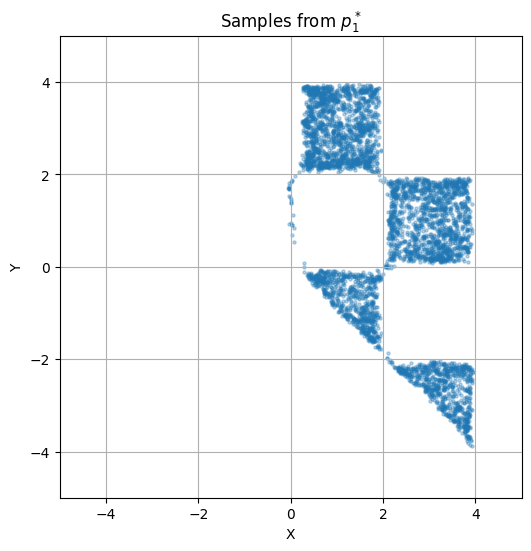

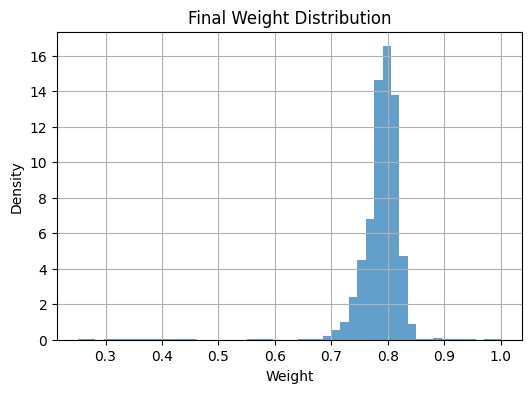

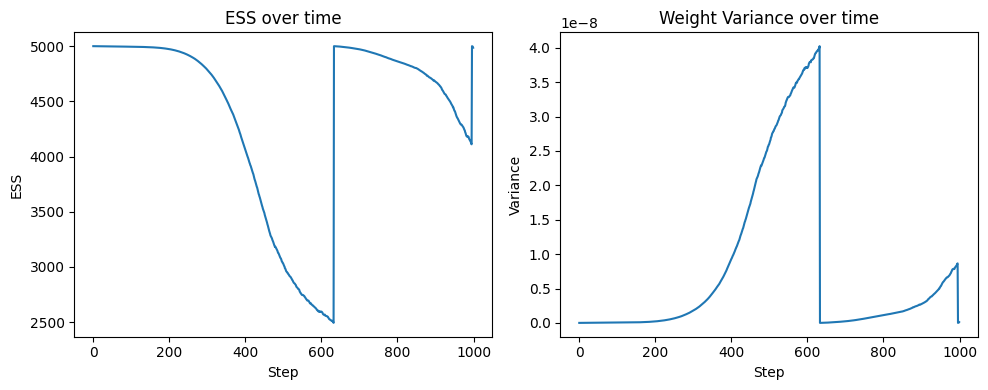

In [3]:
x0 = torch.randn(bs, 2).to("cuda")  # (X, Y) sample
A, B = 1, 1  # Conditioning values

samples, logw_final, logw_history, sample_history, resample_history = simulate_hcg_generalized(
    x0=x0, 
    dim_list=[1, 1, 2],  # dims for q^1(X|A), q^2(X), q^3(Z|B)
    v_fn_list=[
        lambda x, t: v1_fn(x[:, :1], t, torch.full((x.size(0), 1), A, device=x.device)), # v1(X|A)
        lambda x, t: v2_fn(x[:, :1], t),                                                 # v2(X)
        lambda x, t: v3_fn(x, t, torch.full((x.size(0), 1), B, device=x.device))         # v3(Z|B)
    ],
    s_fn_list=[
        lambda x, t: s1_fn(x[:, :1], t, torch.full((x.size(0), 1), A, device=x.device)), # s1(X|A)
        lambda x, t: s2_fn(x[:, :1], t),                                                 # s2(X)
        lambda x, t: s3_fn(x, t, torch.full((x.size(0), 1), B, device=x.device))         # s3(Z|B)
    ],
    gamma_list=[1, -1, 1],     # from log-weight increment in simulate_hcg
    proj_list=[
        lambda z: z[:, :1],    # project to X 
        lambda z: z[:, :1],    # project to X
        lambda z: z            # identity for Z
    ],
    emb_list=[
        lambda x: torch.cat([x, torch.zeros(x.size(0), 1, device=x.device)], dim=1),  # embed X→Z
        lambda x: torch.cat([x, torch.zeros(x.size(0), 1, device=x.device)], dim=1),  # embed X→Z
        lambda z: z  # identity
    ],
    sigma_fn=sigma_fn,
    v_star = lambda z, t: torch.cat([v1_fn(z[:, :1], t, torch.full((z.size(0), 1), A, device=z.device)), torch.zeros(z.size(0), 1, device=z.device)], dim=1) - torch.cat([v2_fn(z[:, :1], t), torch.zeros(z.size(0), 1, device=z.device)], dim=1) + v3_fn(z,t, torch.full((z.size(0),1), B, device=z.device)), # v_star = v1
    # v_star= lambda z, t: v3_fn(z, t, torch.full((z.size(0), 1), B, device=z.device)), 
    t0=0.0, t1=1.0, n_steps=1000,
    device="cuda",
    resample=True,
    ess_threshold=0.5,
    print_resample_history=True
)
samples = samples.cpu().numpy()
plot_diagnostics(samples, logw_final, logw_history, save_name=f"{experiment_id}/tmp")

if False: # equivalent, less general function call
    z0 = torch.randn(bs, 2).to("cuda")  # (X, Y) sample
    A, B = 1, 1  # Conditioning values

    samples, logw_final, logw_history, sample_history = simulate_hcg(
        z0,     v1_fn, s1_fn,     v2_fn, s2_fn,     v3_fn, s3_fn,     sigma_fn,     A=A, B=B,  # Conditioning values
        t0=0.0, t1=1.0, n_steps=1000, device="cuda", resample=True, perturb=False, ess_threshold=0.5, v_star_type="v1"
    )
    samples = samples.cpu().numpy()
    plot_diagnostics(samples, logw_final, logw_history, save_name=f"{experiment_id}/tmp")

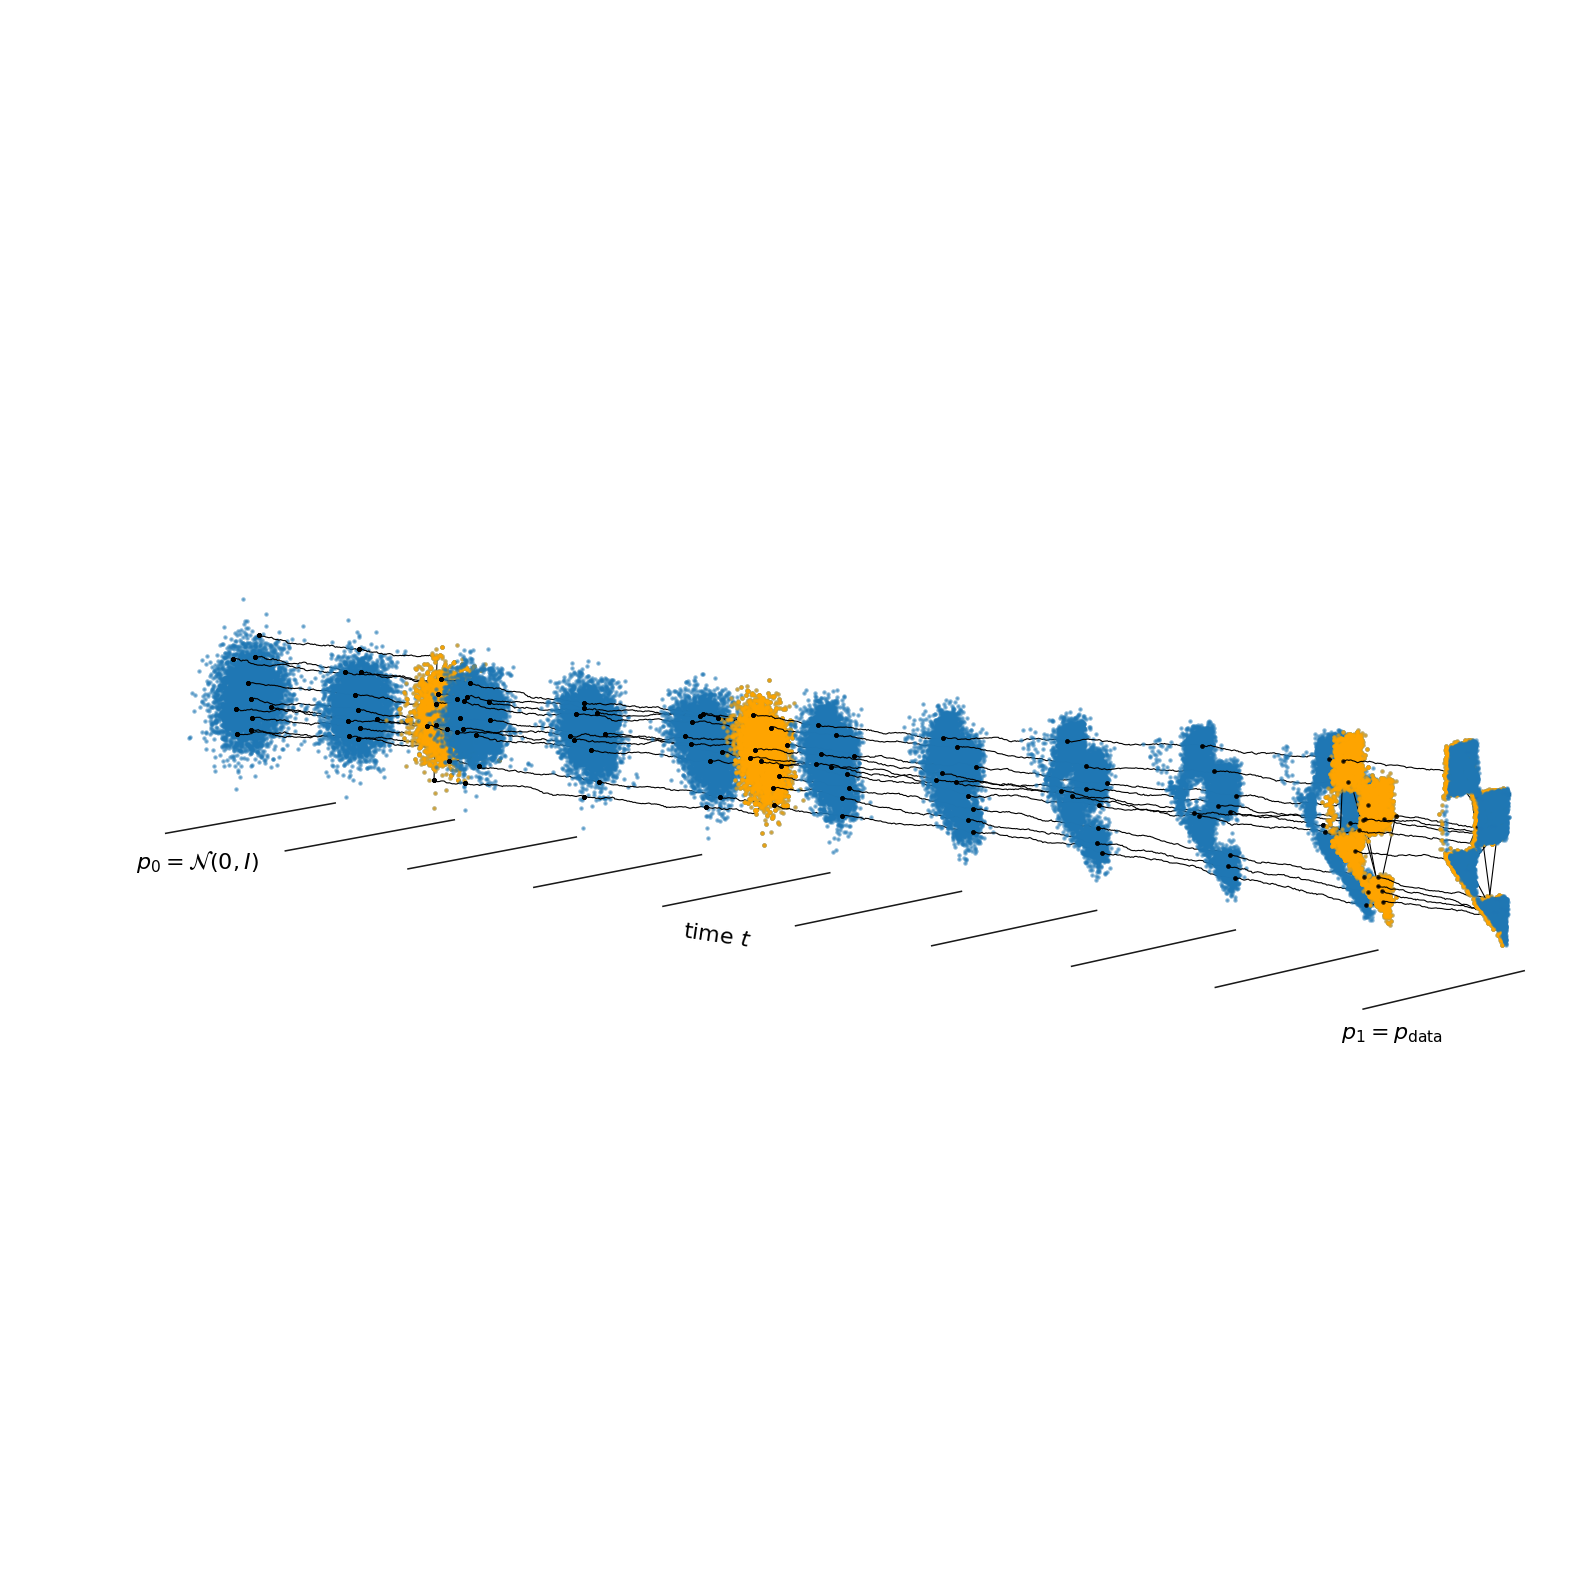

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import torch # Required for placeholder data


# ===================================================================
# 1. User-specified parameters & Setup
# ===================================================================
n_steps = len(sample_history)
n_samples = sample_history[0].shape[0]

# Define which snapshots to show as fractions of the total time. (which makes sense, since the total time ranges from 0 to 1)
snapshot_fractions = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.9999] #[0.0, 0.2, 0.4, 0.6, 0.8, 0.9999]
selected_steps = [int(f * (n_steps - 1)) for f in snapshot_fractions] + resample_history #+ [(i-100) for i in resample_history if i-5 >= 0]
selected_steps = sorted(list(set(selected_steps)))  # Remove duplicates and sort

# Select a few random samples to visualize their full trajectory path.
n_trajectories = 10
trajectory_indices = np.random.choice(n_samples, size=n_trajectories, replace=False)


# ===================================================================
# 2. Plotting Setup
# ===================================================================
all_points = np.concatenate([sample_history[s].cpu().numpy() for s in selected_steps])
ymin, ymax = -5, 5
zmin, zmax = -5, 5

fig = plt.figure(figsize=(10,10), dpi=160)
ax = fig.add_subplot(111, projection='3d', computed_zorder = False)



# ===================================================================
# 3. Visualization (Painter's Algorithm for correct layering)
# ===================================================================

zorder_base = 0  # Base z-order for layering
for i in range(len(selected_steps)):
    current_step = selected_steps[i]

    # --- a) Plot FULLY CONNECTED trajectory segments LEADING TO the current snapshot ---
    if i > 0:
        prev_step = selected_steps[i-1]
        for j in trajectory_indices:
            time_segment = np.arange(prev_step, current_step + 1)
            point_segment = np.array([sample_history[t][j].cpu().numpy() for t in time_segment])
            ax.plot(
                time_segment, 
                point_segment[:, 0], 
                point_segment[:, 1],
                color='black', linewidth=0.5, alpha=1, zorder = zorder_base
            )

            # --- c) Plot highlight dots on trajectories ---
            traj_points = np.array([sample_history[s][j].cpu().numpy() for s in selected_steps])
            ax.scatter(
                selected_steps, traj_points[:, 0], traj_points[:, 1],
                s=1, color='black', linewidths=1, alpha=0.5, depthshade=False, zorder=zorder_base
            )
        zorder_base += 1  # Increment z-order for layering


    # --- b) Plot the snapshot of all samples at the current step ---
    pts = sample_history[current_step].cpu().numpy()
    ax.scatter(
        np.ones(n_samples) * current_step, pts[:, 0], pts[:, 1],
        s=1, alpha=0.5, color='tab:blue', depthshade=False, zorder = zorder_base
    )

    if current_step in resample_history:
        # --- d) Plot resampled points with a different color ---
        zorder_base += 1  # Increment z-order for layering
        ax.scatter(
            np.ones(n_samples) * current_step, pts[:, 0], pts[:, 1],
            s=1, alpha=0.5, color='orange', depthshade=False, zorder = zorder_base
        )

    zorder_base += 1  # Increment z-order for layering


    

# ===================================================================
# 4. Final Plot Styling
# ===================================================================
# --- Set axis limits and aspect ratio ---
ax.set_xlim(0, n_steps - 1)
ax.set_ylim(ymin, ymax)
ax.set_zlim(zmin, zmax)

# **CHANGE**: Adjusted aspect ratio to make the 2D planes appear wider.
ax.set_box_aspect((0.4 * len(selected_steps), 1, 1)) # (x, y, z)

# --- Floor lines and labels ---
y_floor = 0 #ax.get_ylim()[0] # Get bottom y-limit
z_floor = ax.get_zlim()[0] # Get bottom z-limit

# **CHANGE**: Reverted to horizontal floor axes like the original code.
y_tick_size = (ymax - ymin) * 0.5 # Proportional tick size
n_ground_lines = 10
x_positions = np.linspace(0, n_steps - 1, n_ground_lines)
for x_pos in x_positions:
    ax.plot([x_pos, x_pos], [y_floor - y_tick_size, y_floor + y_tick_size], [z_floor, z_floor],
            color="black", linewidth=0.7, alpha=0.9)

# **CHANGE**: Reverted to the original, more descriptive labels.
label_offset = (ymax - ymin) * 0.3 # Proportional offset for labels
ax.text(-label_offset, y_floor - label_offset, z_floor - 0.3 * label_offset, r"$p_0=\mathcal{N}(0,I)$", fontsize=10, ha='center', va='top')
ax.text(n_steps - 1 - label_offset, y_floor - label_offset, z_floor - 0.3 * label_offset, r"$p_1=p_\text{data}$", fontsize=10, ha='center', va='top')

# --- Customize axis ticks and labels ---
ax.set_xlabel("time $t$")
ax.set_xticks([])

# Hide y and z axes for a cleaner look
ax.set_ylabel(""); ax.set_yticks([])
ax.set_zlabel(""); ax.set_zticks([])

# --- Remove panes and grid ---
ax.xaxis.pane.set_alpha(0)
ax.xaxis.pane.set_visible(False)
ax.xaxis.line.set_color((1,1,1,0))

ax.yaxis.pane.set_alpha(0)
ax.yaxis.pane.set_visible(False)
ax.yaxis.line.set_color((1,1,1,0))

ax.zaxis.pane.set_alpha(0)
ax.zaxis.pane.set_visible(False)
ax.zaxis.line.set_color((1,1,1,0))
ax.grid(False)


# --- Set camera angle ---
ax.view_init(elev=9, azim=-50)

plt.tight_layout()
plt.show()

In [10]:
results = []
samples_gt = ground_truth_hcg(bs, cond_A=A, cond_B=B).numpy()
w1, w2, mmd_rbf, total_var = compute_sample_based_metrics(
    torch.tensor(samples_gt), torch.tensor(samples)
)
results.append([w1, w2, mmd_rbf, total_var])
print(results)

[[0.2658444344394053, 0.3313765188797443, 0.060362279415130615, np.float64(0.807067335004177)]]


# FKC Baseline - Homogenized Distributions + FKC

### Define homogenized $q^{(1)}$ and $q^{(2)}$.

Extend each 1D density in $X$ to a 2D one by multiplying with a simple factor in $Y$:

$$
q^{(1)}(x,y \mid A) = q^{(1)}(x \mid A) \cdot f(y),
$$

$$
q^{(2)}(x,y) = q^{(2)}(x)\cdot f(y),
$$

where $f(y)$ is a Gaussian $ \mathcal{N}(0,1)$ or uniform on $[-M,M]$.

Then their score functions decompose:

* For $q^{(1)}$:

$$
s^{(1)}(x,y) = \Big(\,\nabla_x \log q^{(1)}(x \mid A), \;\nabla_y \log f(y)\,\Big),
$$

* For $q^{(2)}$:

$$
s^{(2)}(x,y) = \Big(\,\nabla_x \log q^{(2)}(x), \;\nabla_y \log f(y)\,\Big),
$$

* For $q^{(3)}$ (already 2D): $s^{(3)}(x,y)$ as usual.

So you just need to implement `f(y)` and its score.

### Choosing $f(y)$

* If **Gaussian $f(y)\sim\mathcal{N}(0,1)$**: score is just `-y`.
* If **Uniform on \[-M,M]**: score is `0` inside, but undefined at boundary → you’d need to enforce absorbing or reflecting boundaries in simulation. Much easier to stick with Gaussian unless you want hard support constraints.

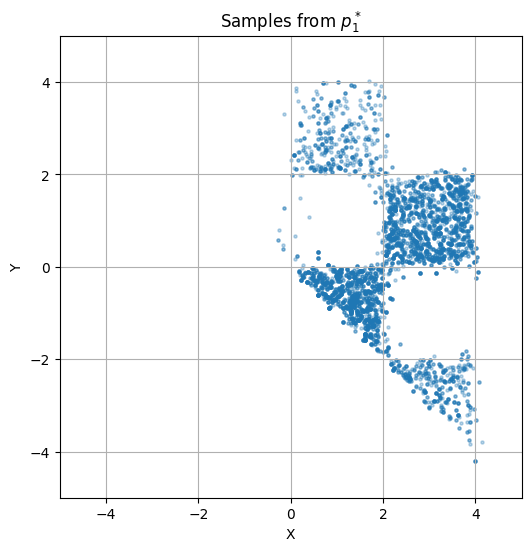

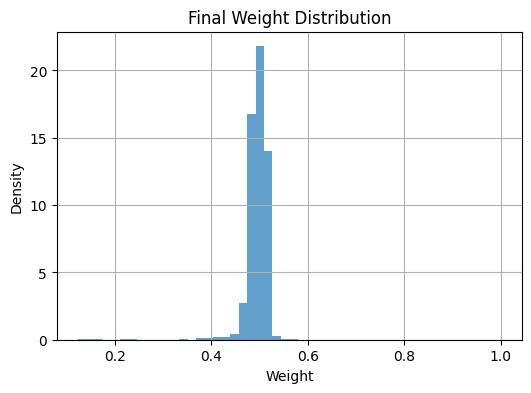

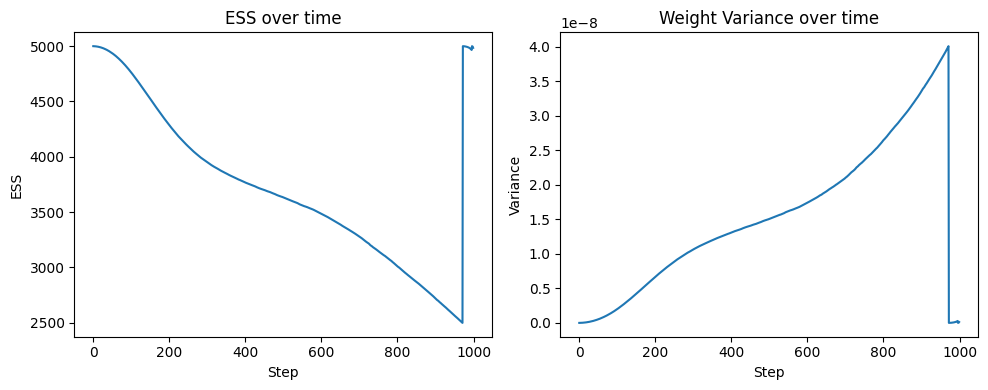

In [19]:
x0 = torch.randn(bs, 2).to("cuda")  # (X, Y) sample
A, B = 1, 1  # Conditioning values
# choose f(y) = N(0, 1)  => score s_f(y) = -y
def s_fp(y):           # y has shape (bs,1)
    return -y
def s_fn(y):           # y has shape (bs,1)
    return -0.5*y # -0.5*y
def v_fp(y, t):        # choose zero deterministic drift in y
    return torch.zeros_like(y)
def v_fn(y, t):        # choose zero deterministic drift in y
    return torch.zeros_like(y)

# build v_fn_list and s_fn_list that return 2D vectors for (x,y)
v_fn_list = [
    lambda z, t: torch.cat([ v1_fn(z[:, :1], t, torch.full((z.size(0), 1), A, device=z.device)), v_fp(z[:, 1:2], t) ], dim=1),
    lambda z, t: torch.cat([ v2_fn(z[:, :1], t),            v_fn(z[:, 1:2], t) ], dim=1),
    lambda z, t: v3_fn(z, t, torch.full((z.size(0), 1), B, device=z.device))   # already 2D
]
s_fn_list = [
    lambda z, t: torch.cat([ s1_fn(z[:, :1], t, torch.full((z.size(0), 1), A, device=z.device)), s_fp(z[:, 1:2]) ], dim=1),
    lambda z, t: torch.cat([ s2_fn(z[:, :1], t),            s_fn(z[:, 1:2]) ], dim=1),
    lambda z, t: s3_fn(z, t, torch.full((z.size(0), 1), B, device=z.device))   # already 2D
]
# pass identity projections since all are now 2D
proj_list = [lambda z: z, lambda z: z, lambda z: z]
emb_list = [lambda z: z, lambda z: z, lambda z: z]
# v_star: extend original v1 in x and zero in y
v_star = lambda z, t: v3_fn(z, t, torch.full((z.size(0), 1), B, device=z.device))
#lambda z, t: torch.cat([ v1_fn(z[:, :1], t, torch.full((z.size(0), 1), A, device=z.device)), torch.zeros(z.size(0), 1, device=z.device) ], dim=1)


samples, logw_final, logw_history, sample_history = simulate_hcg_generalized(
    x0=x0, 
    dim_list=[2, 2, 2],  # dims for q^1(X|A), q^2(X), q^3(Z|B)
    v_fn_list=v_fn_list,
    s_fn_list=s_fn_list,
    gamma_list=[1, -1, 1],     # from log-weight increment in simulate_hcg
    proj_list=proj_list,
    emb_list=emb_list,
    sigma_fn=sigma_fn,
    v_star=v_star,
    t0=0.0, t1=1.0, n_steps=1000,
    device="cuda",
    resample=True,
    ess_threshold=0.5
)
samples = samples.cpu().numpy()
plot_diagnostics(samples, logw_final, logw_history, save_name=f"{experiment_id}/fkc-1")

In [6]:
results = []
samples_gt = ground_truth_hcg(bs, cond_A=A, cond_B=B).numpy()
w1, w2, mmd_rbf, total_var = compute_sample_based_metrics(
    torch.tensor(samples_gt), torch.tensor(samples)
)
results.append([w1, w2, mmd_rbf, total_var])
print(results)

[[0.9622893957155803, 1.261080953917201, 0.17149275541305542, np.float64(0.7735295774647888)]]


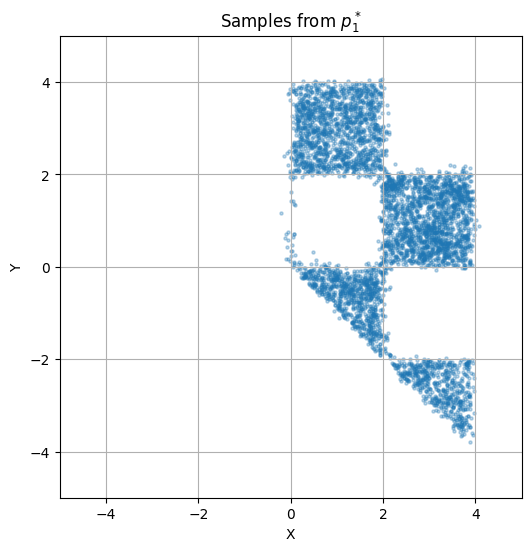

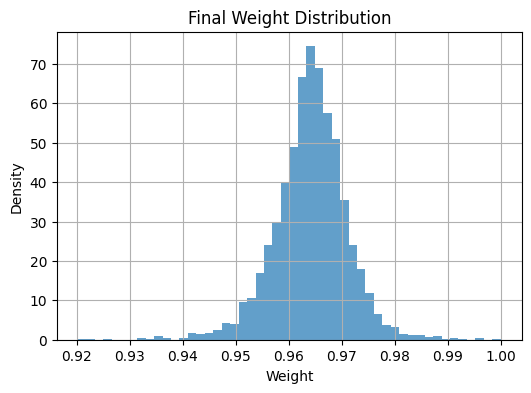

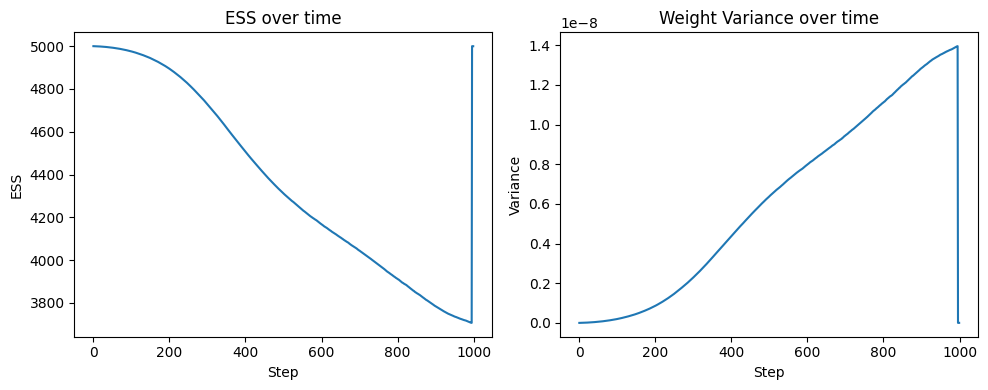

In [4]:
# Product of Experts

x0 = (1/torch.sqrt(torch.tensor(2)))* torch.randn(bs, 2).to("cuda")  # (X, Y) sample
A, B = 1, 1  # Conditioning values

samples, logw_final, logw_history, sample_history = simulate_hcg_generalized(
    x0=x0, 
    dim_list=[1, 2],  # dims for q^1(X|A), q^2(X), q^3(Z|B)
    v_fn_list=[
        lambda x, t: v1_fn(x[:, :1], t, torch.full((x.size(0), 1), A, device=x.device)), # v1(X|A)
        lambda x, t: v3_fn(x, t, torch.full((x.size(0), 1), B, device=x.device))         # v3(Z|B)
    ],
    s_fn_list=[
        lambda x, t: s1_fn(x[:, :1], t, torch.full((x.size(0), 1), A, device=x.device)), # s1(X|A)
        lambda x, t: s3_fn(x, t, torch.full((x.size(0), 1), B, device=x.device))         # s3(Z|B)
    ],
    gamma_list=[1, 1],     # from log-weight increment in simulate_hcg
    proj_list=[
        lambda z: z[:, :1],    # project to X
        lambda z: z            # identity for Z
    ],
    emb_list=[
        lambda x: torch.cat([x, torch.zeros(x.size(0), 1, device=x.device)], dim=1),  # embed X→Z
        lambda z: z  # identity
    ],
    sigma_fn=sigma_fn,
    #lambda z, t: torch.cat([v1_fn(z[:, :1], t, torch.full((z.size(0), 1), A, device=z.device)), torch.zeros(z.size(0), 1, device=z.device)], dim=1), # v_star = v1
    v_star= lambda z, t: v3_fn(z, t, torch.full((z.size(0), 1), B, device=z.device)), 
    t0=0.0, t1=1.0, n_steps=1000,
    device="cuda",
    resample=True,
    ess_threshold=0.5
)
samples = samples.cpu().numpy()
plot_diagnostics(samples, logw_final, logw_history, save_name=f"{experiment_id}/tmp")

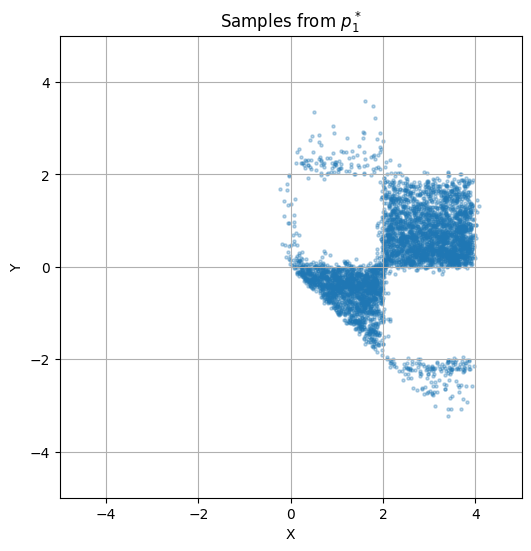

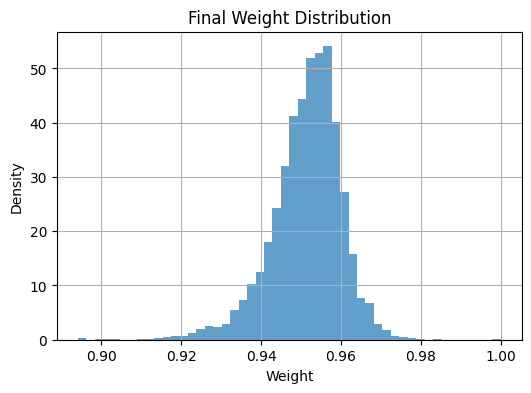

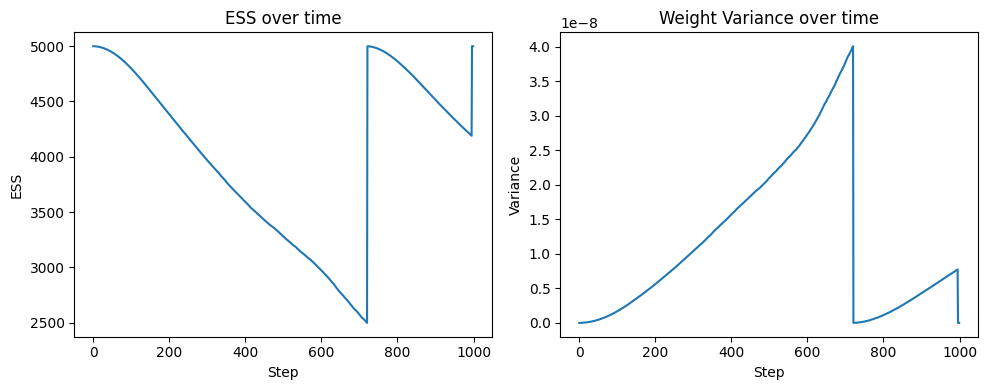

In [ ]:
x0 = (1/torch.sqrt(torch.tensor(2))) * torch.randn(bs, 2).to("cuda")  # (X, Y) sample
A, B = 1, 1  # Conditioning values

# choose f(y) = N(0, 1)  => score s_f(y) = -y
def s_f(y):           # y has shape (bs,1)
    return -y
def v_f(y, t):        # choose zero deterministic drift in y
    return torch.zeros_like(y)

v_fn_list = [
    lambda z, t: torch.cat([ v1_fn(z[:, :1], t, torch.full((z.size(0), 1), A, device=z.device)), v_f(z[:, 1:2], t) ], dim=1),
    lambda z, t: v3_fn(z, t, torch.full((z.size(0), 1), B, device=z.device))   # already 2D
]
s_fn_list = [
    lambda z, t: torch.cat([ s1_fn(z[:, :1], t, torch.full((z.size(0), 1), A, device=z.device)), s_f(z[:, 1:2]) ], dim=1),
    lambda z, t: s3_fn(z, t, torch.full((z.size(0), 1), B, device=z.device))   # already 2D
]
proj_list = [lambda z: z, lambda z: z]
emb_list = [lambda z: z, lambda z: z]
v_star = lambda z, t: v3_fn(z, t, torch.full((z.size(0), 1), B, device=z.device))


samples, logw_final, logw_history, sample_history = simulate_hcg_generalized(
    x0=x0, 
    dim_list=[2, 2],
    v_fn_list=v_fn_list,
    s_fn_list=s_fn_list,
    gamma_list=[1, 1],     # from log-weight increment in simulate_hcg
    proj_list=proj_list,
    emb_list=emb_list,
    sigma_fn=sigma_fn,
    v_star=v_star,
    t0=0.0, t1=1.0, n_steps=1000,
    device="cuda",
    resample=True,
    ess_threshold=0.5
)
samples = samples.cpu().numpy()
plot_diagnostics(samples, logw_final, logw_history, save_name=f"{experiment_id}/fkc-1")

# Evaluation with Metrics

Following the FKC paper, we sample 10k samples with 1000 sampling steps.

In [ ]:
import os
import torch
import numpy as np
import pandas as pd
from utils.metrics.export import compute_sample_based_metrics

# torch.set_num_threads(16)  # adjust for your CPU


bs = 5000  # batch size
seeds = [0] #[1, 2]
v_star_types = ["v1"] #["v1", "v2", "v3", "v1+v2+v3"]
ess_thresholds = [0.5] #[0.1, 0.5, 0.9]
all_results = []
os.makedirs(f"{experiment_id}/plot_diagnostics", exist_ok=True)

for seed in seeds:
    gtvsgt = True # Run once per seed
    for v_star_type in v_star_types:
        for ess_threshold in ess_thresholds:
            print(f"Running seed {seed} with v_star_type {v_star_type} and ess_threshold {ess_threshold}...")

            ### RUN EXPERIMENT
            torch.manual_seed(seed)
            np.random.seed(seed)

            z0 = torch.randn(bs, 2).to("cuda")  # (X, Y) sample
            A, B = 1, 1

            # Simulations
            methods = {}
            methods["Baseline"], logw_final, logw_history, _ = simulate_hcg(
                z0, v1_fn, s1_fn, v2_fn, s2_fn, v3_fn, s3_fn, sigma_fn,
                A=A, B=B, t0=0.0, t1=1.0, n_steps=1000,
                device="cuda", resample=False, perturb=False, ess_threshold=ess_threshold, v_star_type=v_star_type
            )
            plot_diagnostics(methods["Baseline"].cpu().numpy(), logw_final, logw_history, save_name=f"{experiment_id}/plot_diagnostics/seed{seed}_ess_{ess_threshold}_v_star_{v_star_type}_heuristic")
            
            methods["HCG"], logw_final, logw_history, _ = simulate_hcg(
                z0, v1_fn, s1_fn, v2_fn, s2_fn, v3_fn, s3_fn, sigma_fn,
                A=A, B=B, t0=0.0, t1=1.0, n_steps=1000,
                device="cuda", resample=True, perturb=False, ess_threshold=ess_threshold, v_star_type=v_star_type
            )
            plot_diagnostics(methods["HCG"].cpu().numpy(), logw_final, logw_history, save_name=f"{experiment_id}/plot_diagnostics/seed{seed}_ess_{ess_threshold}_v_star_{v_star_type}_hcg")

            # Convert to numpy
            methods = {k: v.cpu().numpy() for k, v in methods.items()}

            # Metrics
            results = []
            samples_gt = ground_truth_hcg(bs, cond_A=A, cond_B=B).numpy()
            for method_name, samples in methods.items():
                w1, w2, mmd_rbf, total_var = compute_sample_based_metrics(
                    torch.tensor(samples_gt), torch.tensor(samples)
                )
                results.append([seed, v_star_type, ess_threshold, method_name, w1, w2, mmd_rbf, total_var])

            # GT vs GT sanity check
            # Ground truth
            if gtvsgt:
                gtvsgt = False # Only run once per seed
                samples_gt_ref = ground_truth_hcg(bs, cond_A=A, cond_B=B).numpy()
                w1, w2, mmd_rbf, total_var = compute_sample_based_metrics(
                    torch.tensor(samples_gt), torch.tensor(samples_gt_ref)
                )
                results.append([seed, v_star_type, ess_threshold, "GTvsGT", w1, w2, mmd_rbf, total_var])

            ### COLLECT RESULTS
            all_results.extend(results)  

df = pd.DataFrame(all_results, columns=["seed", "v_star_type", "ess", "method", "W1", "W2", "MMD_RBF", "Total Var."])
df.to_csv(f"{experiment_id}/experiment_results_numseeds{len(seeds)}_bs{bs}.csv", index=False)
print(df)

# Training Script

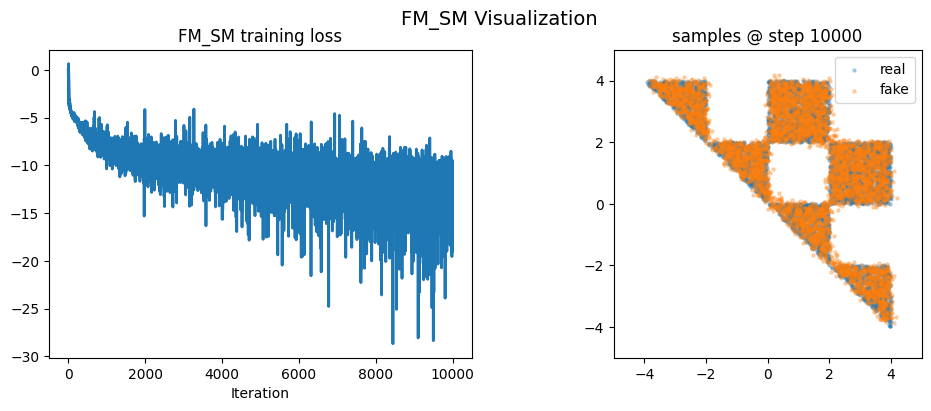

In [ ]:
if False:
    u_model1 = MLPInstFlexible(z_dim=1, cond_dim=1, width=256, depth=4, output_dim=1).to(device) # X | A
    s_model1 = MLPInstFlexible(z_dim=1, cond_dim=1, width=256, depth=4, output_dim=1).to(device) # X | A
    run_training_v_s(u_model1, s_model1, sample_data_model1, plot_cond_val=1.0, n_iters=2000)
    torch.save(u_model1.state_dict(), f"{experiment_id}/u_model1_X_given_A.pth")
    torch.save(s_model1.state_dict(), f"{experiment_id}/s_model1_X_given_A.pth")
if False:
    u_model3 = MLPInstFlexible(z_dim=1, cond_dim=0, width=256, depth=4, output_dim=1).to(device) # X
    s_model3 = MLPInstFlexible(z_dim=1, cond_dim=0, width=256, depth=4, output_dim=1).to(device) # X
    run_training_v_s(u_model3, s_model3, sample_data_model3, n_iters=2000)
    torch.save(u_model3.state_dict(), f"{experiment_id}/u_model3_X.pth")
    torch.save(s_model3.state_dict(), f"{experiment_id}/s_model3_X.pth")
if False:
    u_model2 = MLPInstFlexible(z_dim=2, cond_dim=1, width=256, depth=4, output_dim=2).to(device) # X, Y | B
    s_model2 = MLPInstFlexible(z_dim=2, cond_dim=1, width=256, depth=4, output_dim=2).to(device) # X, Y | B
    run_training_v_s(u_model2, s_model2, sample_data_model2, plot_cond_val=1.0, n_iters=10000)
    torch.save(u_model2.state_dict(), f"{experiment_id}/u_model2_XY_given_B.pth")
    torch.save(s_model2.state_dict(), f"{experiment_id}/s_model2_XY_given_B.pth")

# Ratio of Experts $q^1/q^2$

In [ ]:
def sample_data_q1(bs, cond=None, id=0):
    """
    Samples from q^1(x): N(-2, 0.5^2)
    `cond` is a dummy argument for compatibility (e.g., A)
    """
    if id == 0:
        return torch.randn(bs, 1, device=device) + (-2.0), None
    elif id == 1:
        mix = torch.bernoulli(0.9 * torch.ones(bs, 1, device=device))
        left = torch.randn(bs, 1, device=device) + (-2.0)
        right = torch.randn(bs, 1, device=device) + (2.0)
        return mix * right + (1 - mix) * left, None

def sample_data_q2(bs, cond=None, id=0):
    """
    Samples from q^2(x): 50% N(-2, 0.5^2) + 50% N(2, 0.5^2)
    `cond` is a dummy argument for compatibility
    """
    if id == 0:
        mix = torch.bernoulli(0.5 * torch.ones(bs, 1, device=device))
        left = torch.randn(bs, 1, device=device) + (-2.0)
        right = torch.randn(bs, 1, device=device) + (2.0)
        return mix * right + (1 - mix) * left, None

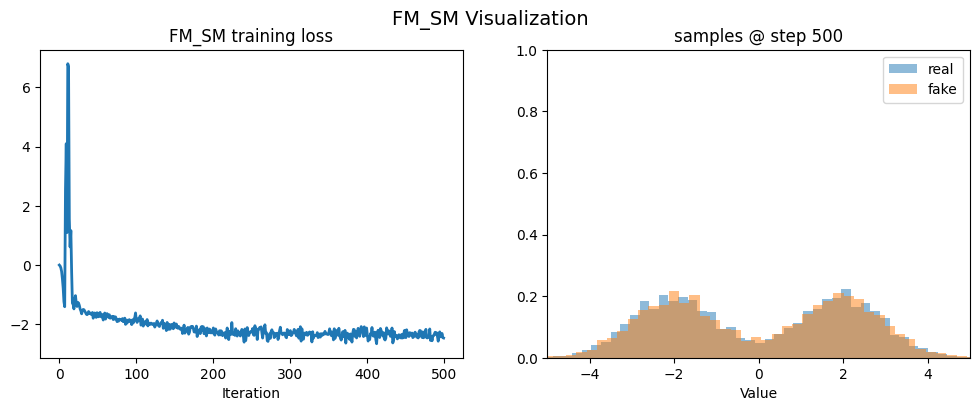

In [ ]:
if True:
    # Training takes ~6s on a single GPU
    u_q1 = MLPInstFlexible(z_dim=1, cond_dim=0, width=256, depth=4, output_dim=1).to(device) # X | A
    s_q1 = MLPInstFlexible(z_dim=1, cond_dim=0, width=256, depth=4, output_dim=1).to(device) # X | A
    run_training_v_s(u_q1, s_q1, sample_data_q1, plot_cond_val=None, n_iters=500)
    # save the models
    torch.save(u_q1.state_dict(), f"{experiment_id}/ratio_u_q1.pth")
    torch.save(s_q1.state_dict(), f"{experiment_id}/ratio_s_q1.pth")
if True:
    # Training takes ~5s on a single GPU
    u_q2 = MLPInstFlexible(z_dim=1, cond_dim=0, width=256, depth=4, output_dim=1).to(device) # X | A
    s_q2 = MLPInstFlexible(z_dim=1, cond_dim=0, width=256, depth=4, output_dim=1).to(device) # X | A
    run_training_v_s(u_q2, s_q2, sample_data_q2, plot_cond_val=None, n_iters=500)
    # save the models
    torch.save(u_q2.state_dict(), f"{experiment_id}/ratio_u_q2.pth")
    torch.save(s_q2.state_dict(), f"{experiment_id}/ratio_s_q2.pth")

In [ ]:
# q1 / q2 where q1 is a guassian centered at -2 and q2 is a guassian centered at 2 and -2

# Load the saved models
u_q1 = MLPInstFlexible(z_dim=1, cond_dim=0, width=256, depth=4, output_dim=1).to(device)
s_q1 = MLPInstFlexible(z_dim=1, cond_dim=0, width=256, depth=4, output_dim=1).to(device)
u_q2 = MLPInstFlexible(z_dim=1, cond_dim=0, width=256, depth=4, output_dim=1).to(device)
s_q2 = MLPInstFlexible(z_dim=1, cond_dim=0, width=256, depth=4, output_dim=1).to(device)
u_q1.load_state_dict(torch.load(f"{experiment_id}/ratio_u_q1.pth"))
s_q1.load_state_dict(torch.load(f"{experiment_id}/ratio_s_q1.pth"))
u_q2.load_state_dict(torch.load(f"{experiment_id}/ratio_u_q2.pth"))
s_q2.load_state_dict(torch.load(f"{experiment_id}/ratio_s_q2.pth"))

# v1: for q^1 (N(-2))
def v1_fn(x, t): return u_q1(x, t)
def s1_fn(x, t): return s_q1(x, t)

# v2: for q^2 (mixture of N(-2), N(+2))
def v2_fn(x, t): return u_q2(x, t)
def s2_fn(x, t): return s_q2(x, t)

# Constant diffusion coefficient
def sigma_fn(t): return torch.ones_like(t)


/tmp/ipykernel_2029843/4289259188.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  u_q1.load_state_dict(torch.load(f"{experiment_id}/ratio_u_q1.pth"))
/tmp/ipykernel_2029

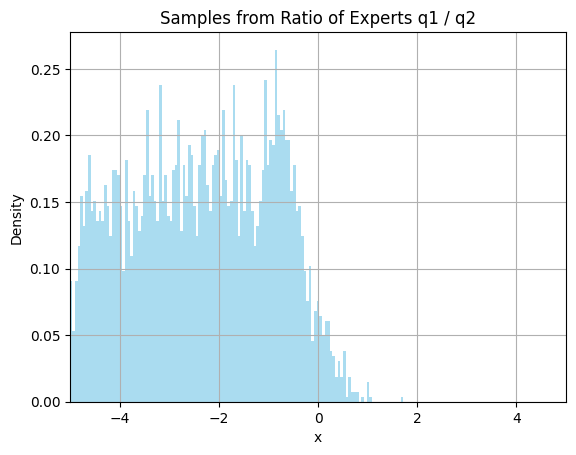

In [ ]:
# Uniform Sample
x0 = torch.rand(bs, 1).to(device) * 10 - 5

samples, logw_final, logw_history, sample_history = simulate_hcg_generalized(
    x0=x0, 
    dim_list=[1, 1], 
    v_fn_list=[
        lambda x, t: v1_fn(x, t),                                                 # v1(X)
        lambda x, t: v2_fn(x, t),                                                 # v2(X)
    ],
    s_fn_list=[
        lambda x, t: s1_fn(x, t),                                                 # s1(X)
        lambda x, t: s2_fn(x, t),                                                 # s2(X)
    ],
    gamma_list=[1, -1],     # from log-weight increment in simulate_hcg
    proj_list=[
        lambda z: z, 
        lambda z: z 
    ],
    emb_list=[
        lambda z: z,  # identity
        lambda z: z  # identity
    ],
    sigma_fn=sigma_fn,
    v_star= lambda z, t: v2_fn(z, t), 
    t0=0.0, t1=1.0, n_steps=1000,
    device="cuda",
    resample=True,
    ess_threshold=0.5
)
samples = samples.cpu().numpy()
plt.hist(samples, bins=200, density=True, alpha=0.7, color="skyblue")
plt.title("Samples from Ratio of Experts q1 / q2")
plt.grid(True)
plt.xlabel("x"); plt.xlim(-5,5)
plt.ylabel("Density")
plt.show()